## Deakin University

## SIG731- Data Wrangling

**Name:** Surendra Bahadur Rai

**Email:** s223940212@deakin.com

**Student ID:** s223940212

## Task 2

This task is related to Module 2 (Sections 2.1-2.4) Learning Practice Exercises.
Using the NumPy library and Pandas, I have learned in this unit how to use the NumPy library for data manipulation and efficiently apply data wrangling techniques using library features. This task is Basically Trading BTC Analysis of Historical data from 2023-01-01 up to 2023-12-31 and To Find the Based on Data Investor Status Global Impact of Crypto markets


### Objective of the Task
The primary objective is to perform a trading analysis of Bitcoin (BTC) using historical data from January 1, 2023, to December 31, 2023. The analysis aims to:

- Understand BTC price fluctuations over the year.
- Identify significant patterns or anomalies.
- Evaluate the global impact of cryptocurrency markets on investors' behavior and market dynamics.

### Q1. Download the daily close BTC-to-USD data, from 2023-01-01 up to 2023-12-31, available at 
https://finance.yahoo.com/quote/BTC-USD (the Historical Data tab).




In [1]:
#Importing Pakage Library

import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Declare tiker symbol and start date and end date
ticker_symbol = "BTC-USD"
start_date = "2023-01-01"
end_date = "2023-12-31"
# Fetch the data Using  yfinace libray
btc_data = yf.download(ticker_symbol, start=start_date, end=end_date, progress=False)

Here, set the start date to 2023-01-01 and the end date to 2023-12-31 to download historical data.

In [3]:
#just print the Head 5 elments
btc_data.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700
2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227
2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207
2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322
2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566


The Yfinance library uses a Pandas DataFrame to display data in a tabular view. The headings represent columns, and here, 3 rows of data are being shown.

In [4]:
#BTC Symbol data shape
btc_data.shape

(364, 5)

In [5]:
# Save to a CSV file (optional)
btc_data.to_csv("BTC_USD_2023.csv")

In [6]:
# Keep only the 'Close' column
btc_close_data = btc_data[['Close']]

# Save to a CSV file only Daily close
btc_close_data.to_csv("BTC_USD_Daily_Close_2023.csv")

In [7]:
btc_close_data

Price,Close
Ticker,BTC-USD
Date,
2023-01-01,16625.080078
2023-01-02,16688.470703
2023-01-03,16679.857422
2023-01-04,16863.238281
2023-01-05,16836.736328
...,...
2023-12-26,42520.402344
2023-12-27,43442.855469


Here, data only shown Daily Trading  close Colum and Date  & Heading 3 rows showing 

### Q2. Use numpy.genfromtxt or numpy.loadtxt to read the above BTC-to-USD data as a numpy vector named rates.

In [8]:
# Use numpy.genfromtxt Reading Historical data
rates = np.genfromtxt("BTC_USD_2023.csv", delimiter=",", skip_header=3, usecols=1)

# Print the first few rates to verify
print("Rates as a NumPy vector:")
print(rates)

Rates as a NumPy vector:
[16625.08007812 16688.47070312 16679.85742188 16863.23828125
 16836.73632812 16951.96875    16955.078125   17091.14453125
 17196.5546875  17446.29296875 17934.89648438 18869.58789062
 19909.57421875 20976.29882812 20880.79882812 21169.6328125
 21161.51953125 20688.78125    21086.79296875 22676.55273438
 22777.625      22720.41601562 22934.43164062 22636.46875
 23117.859375   23032.77734375 23078.72851562 23031.08984375
 23774.56640625 22840.13867188 23139.28320312 23723.76953125
 23471.87109375 23449.32226562 23331.84765625 22955.66601562
 22760.109375   23264.29101562 22939.3984375  21819.0390625
 21651.18359375 21870.875      21788.203125   21808.1015625
 22220.8046875  24307.84179688 23623.47460938 24565.6015625
 24641.27734375 24327.64257812 24829.1484375  24436.35351562
 24188.84375    23947.4921875  23198.12695312 23175.375
 23561.21289062 23522.87109375 23147.35351562 23646.55078125
 23475.46679688 22362.6796875  22353.34960938 22435.51367188
 22429.7578

This all Historical  data of BTC Symbol to 2023-01-01 and the end date to 2023-12-31  in numpy vector, and avoiding header skip_header=3 

In [9]:
# Use numpy.genfromtxt Reading Daily close Symbol oly skipping Header 3 rows only for data
rates1 = np.genfromtxt("BTC_USD_Daily_Close_2023.csv", delimiter=",", skip_header=3, usecols=1)

# Printting the Numpy Array vector
print("Rates as a NumPy vector:")
print(rates1)

Rates as a NumPy vector:
[16625.08007812 16688.47070312 16679.85742188 16863.23828125
 16836.73632812 16951.96875    16955.078125   17091.14453125
 17196.5546875  17446.29296875 17934.89648438 18869.58789062
 19909.57421875 20976.29882812 20880.79882812 21169.6328125
 21161.51953125 20688.78125    21086.79296875 22676.55273438
 22777.625      22720.41601562 22934.43164062 22636.46875
 23117.859375   23032.77734375 23078.72851562 23031.08984375
 23774.56640625 22840.13867188 23139.28320312 23723.76953125
 23471.87109375 23449.32226562 23331.84765625 22955.66601562
 22760.109375   23264.29101562 22939.3984375  21819.0390625
 21651.18359375 21870.875      21788.203125   21808.1015625
 22220.8046875  24307.84179688 23623.47460938 24565.6015625
 24641.27734375 24327.64257812 24829.1484375  24436.35351562
 24188.84375    23947.4921875  23198.12695312 23175.375
 23561.21289062 23522.87109375 23147.35351562 23646.55078125
 23475.46679688 22362.6796875  22353.34960938 22435.51367188
 22429.7578

Only Closed BTC Symbol to 2023-01-01 and the end date to 2023-12-31 in numpy vector

### Q3. For the fourth quarter of the year only (Q4 2023; days 274–365 inclusive),determine and display(in a readable manner) the following aggregates:

* arithmetic mean
* minimum
* the first quartile,
* median,
* the third quartile,
* maximum,
* standard deviation,
* interquartile range.

In [10]:
# Filter the data for the fourth quarter (q4 2023) (days 274–365 inclusive)
q4_data = btc_data.loc['2023-10-01':'2023-12-31']

# Extract the 'Close' prices
q4_close = q4_data['Close']

# Calculate the desired aggregates using scipy and numpy
aggregates = {
    'Arithmetic Mean': np.mean(q4_close),
    'Minimum': np.min(q4_close),
    'First Quartile (Q1)': np.percentile(q4_close, 25),
    'Median': np.median(q4_close),
    'Third Quartile (Q3)': np.percentile(q4_close, 75),
    'Maximum': np.max(q4_close),
    'Standard Deviation': np.std(q4_close),
    'Interquartile Range (IQR)': stats.iqr(q4_close)  # IQR using scipy
}

# Display the aggregates:
print("Q4 2023 BTC-USD Aggregates: \n")
for key, value in aggregates.items():
    print(f"##   {key}: {float(value):.2f}")


Q4 2023 BTC-USD Aggregates: 

##   Arithmetic Mean: 36230.84
##   Minimum: 26756.80
##   First Quartile (Q1): 33493.88
##   Median: 36693.12
##   Third Quartile (Q3): 41954.93
##   Maximum: 44166.60
##   Standard Deviation: 5603.84
##   Interquartile Range (IQR): 8461.05


- Filter the data for the fourth quarter (Q4 2023) (days 274–365 inclusive)
- Extract the 'Close' prices
- Calculate the desired aggregates using scipy and numpy
- Q4 2023 BTC-USD Aggregates values

### Q4. Call matplotlib.pyplot.plot(days, rates, <...further_arguments...>) to draw the Q4 2023 data (with 274 denoting 1 October), using red solid line segments.

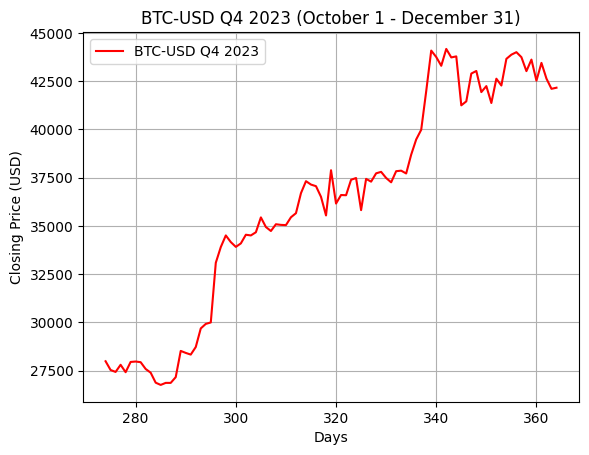

In [11]:
# Filter the data for the fourth quarter (Q4 2023) (days 274–365 inclusive)
q4_data = btc_data.loc['2023-10-01':'2023-12-31']

# Extract the 'Close' prices for Q4
q4_close = q4_data['Close']

# days only in array where day 274 corresponds to October 1, 2023
days = np.arange(274, 274 + len(q4_close))

# Plot the data
plt.plot(days, q4_close, 'r-', label='BTC-USD Q4 2023') 
plt.title('BTC-USD Q4 2023 (October 1 - December 31)') 
plt.xlabel('Days') 
plt.ylabel('Closing Price (USD)') 
plt.grid(True) 
plt.legend()
plt.show()

- Filter the data for the fourth quarter (Q4 2023) (days 274–365 inclusive)
- Extract the 'Close' prices for Q4
- Create the 'days' in arry list where day 274 corresponds to October 1, 2023
- using matplot lib libray & Plot line graph of  data only BTC-USD Q4 2023 (October 1 - December 31)

### Q5. Determine the day numbers (with 274 denoting 1 October) with the lowest and highest observed prices in Q4 2023. Below is an example of the lowest and highest price days in Q3 2023.

In [12]:
# Filter the data for the fourth quarter (Q4 2023) (days 274–365 inclusive)
q4_data = btc_data.loc['2023-10-01':'2023-12-31']

# Extract the 'Close' prices for Q4
q4_close = q4_data['Close']

# Find the 'days' array where day 274 corresponds to October 1, 2023
days = np.arange(274, 274 + len(q4_close))

# Find the day with the lowest price
min_price = np.min(q4_close)
min_day = days[np.argmin(q4_close)]

# Find the day with the highest price
max_price = np.max(q4_close)
max_day = days[np.argmax(q4_close)]

# Print the results
print(f"## Lowest price was on day {min_day} ({min_price:.2f}).")
print(f"## Highest price was on day {max_day} ({max_price:.2f}).")

## Lowest price was on day 285 (26756.80).
## Highest price was on day 342 (44166.60).



- Filter the data for the fourth quarter (Q4 2023) (days 274–365 inclusive)
- Extract the 'Close' prices for Q4
- Find the 'days' array where day 274 corresponds to October 1, 2023
- Find the day with the lowest price using numpy.min of the close price
- Find the day with the highest price using numpy.max of the close price
- Print the results

### Q6. Using matplotlib.pyplot.boxplot, draw a horizontal box-and-whisker plot for the Q4 2023 daily price increases/decreases as obtained by a call to numpy.diff.

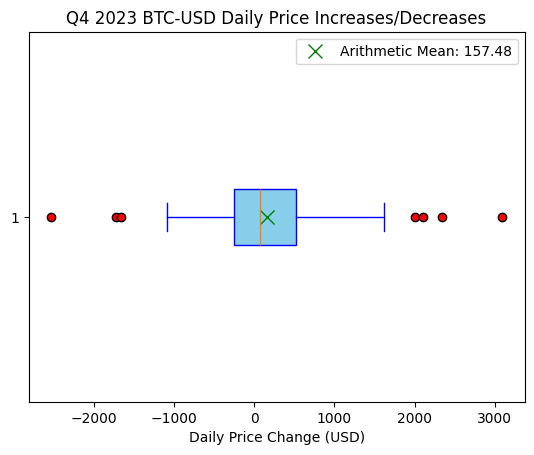

In [13]:
# Filter the data for the fourth quarter (Q4 2023)
q4_data = btc_data.loc['2023-10-01':'2023-12-31']

# Find the close column 
q4_close = q4_data['Close'].values

# Calculate the daily price increases/decreases using numpy.diff()
daily_changes = np.diff(q4_close,axis=0)

# Create the horizontal boxplot for the daily price changes
plt.boxplot(daily_changes, vert=False, patch_artist=True, boxprops=dict(facecolor='skyblue', color='blue'), 
            whiskerprops=dict(color='blue'), capprops=dict(color='blue'), flierprops=dict(markerfacecolor='red', marker='o'))

# Mark the arithmetic mean on the boxplot with a green "x"
mean_change = np.mean(daily_changes)
plt.plot(mean_change, 1, 'gx', markersize=10, label=f'Arithmetic Mean: {mean_change:.2f}')
# Add labels and title
plt.xlabel('Daily Price Change (USD)')
plt.title('Q4 2023 BTC-USD Daily Price Increases/Decreases')
plt.legend()
plt.show()

- Filter the data for the fourth quarter (Q4 2023)
- Find the close column price
- Calculate the daily price increases/decreases using numpy.diff()
- Create the horizontal boxplot for the daily price changes
- Mark the arithmetic mean on the boxplot with a green "x"
- Add labels and title

#### Learning outcome of this Question is
Box plot display:

**Median:** The central line in the box.

**Interquartile Range (IQR):** The box's length.

**Whiskers:** Extend to the smallest and largest data points within 1.5×IQR.

**Outliers:** showing data point of the whiskers.

### Q7. Count (programmatically,using the vectorised relational operators from numpy) how many outliers the boxplot contains (for the definition of an outlier, consult Section 2.3 of our learning materials on the unit site or Section 5.1 in the Book)

In [14]:
# Filter the data
q4_data = btc_data.loc['2023-10-01':'2023-12-31']

# Find the 'Close' prices for Q4
q4_close = q4_data['Close'].values

# Calculate the daily price increases/decreases using numpy.diff()
daily_changes = np.diff(q4_close,axis=0)

#Compute Q1, Q3, and IQR
Q1 = np.percentile(daily_changes, 25)
Q3 = np.percentile(daily_changes, 75)
IQR = Q3 - Q1

# Calculate the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count the outliers using numpy's relational operators
outliers = (daily_changes < lower_bound) | (daily_changes > upper_bound)
num_outliers = np.sum(outliers)

# Output the result
print(f"Number of outliers: {num_outliers}")

Number of outliers: 7


Heres did this step

- Filter the data
- Find the 'Close' prices for Q4
- Compute Q1, Q3, and IQR
- Count the outliers using numpy's relational operators
- Output the result

#### Outliers in a boxplot are defined as data points: 

$Q1 − 1.5×IQR $ (lower bound)

or 

$Q3+1.5×IQR $(upper bound), where

- $Q1$: First quartile (25th percentile).
- $Q3$: Third quartile (75th percentile).
- $IQR$: Interquartile range ($Q3−Q1$).


***Discription:**

Outliers in this context represent unusually large price increases or decreases in Bitcoin's daily closing prices during Q4 2023. These could be caused by:

- **Market Volatility**: Significant changes in demand or supply, often driven by external events like regulatory announcements, technological advancements, or macroeconomic factors.

- **Investor Behavior**: Sudden large-scale buying or selling by institutional or retail investors.

- **Global Events**: News impacting the cryptocurrency market, such as government bans, adoption by major companies, or significant hacks.

- **Low Liquidity**: During certain periods, lower market liquidity can amplify price movements, leading to outliers.